# 🧠 Mental Health Intelligence Platform

## Phase 8 — Model Explainability

### Overview

Machine learning models can achieve strong predictive performance, but understanding **why** they make predictions is equally important.

This notebook explains the trained Random Forest model by identifying the features that contribute most to predicting whether an employee is likely to seek professional mental health treatment.

---

### Objectives

- Interpret the trained model
- Identify the most influential features
- Visualize feature importance
- Generate actionable business insights
- Increase transparency and trust in model predictions

In [2]:
import warnings
warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd

import plotly.express as px

from pathlib import Path

## Load Trained Model

In [3]:
best_model = joblib.load("../models/best_model.pkl")

best_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['No','Yes']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](53,)","['survey_year','self_employed','no_employees',...,'state_work','age_group', 'workplace_support_score']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,53
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By 

## Load Dataset

In [4]:
df = pd.read_csv("../data/processed/ml_ready_dataset.csv")

TARGET = "sought_treatment"

X = df.drop(columns=TARGET)

## Extract Feature Names

In [5]:
preprocessor = best_model.named_steps["preprocessor"]

feature_names = preprocessor.get_feature_names_out()

len(feature_names)

304

## Feature Importance

In [6]:
rf = best_model.named_steps["classifier"]

importance = rf.feature_importances_

feature_importance = pd.DataFrame({

    "Feature": feature_names,

    "Importance": importance

})

feature_importance = feature_importance.sort_values(

    "Importance",

    ascending=False

)

feature_importance.head(20)

,Feature,Importance
137,cat__past_disorder_Yes,0.060536
134,cat__past_disorder_No,0.054226
140,cat__family_history_Yes,0.033256
139,cat__family_history_No,0.032913
9,num__workplace_support_score,0.018579
34,cat__know_options_Yes,0.018170
6,num__share_with_friends_family,0.014658
8,num__age,0.012326
69,cat__discussed_with_employer_Yes,0.010689
67,cat__discussed_with_employer_No,0.010656


## Top 20 Most Important Features

Random Forest determines the relative importance of every predictor during model training.

Higher importance indicates a stronger contribution toward predicting whether an individual is likely to seek treatment.

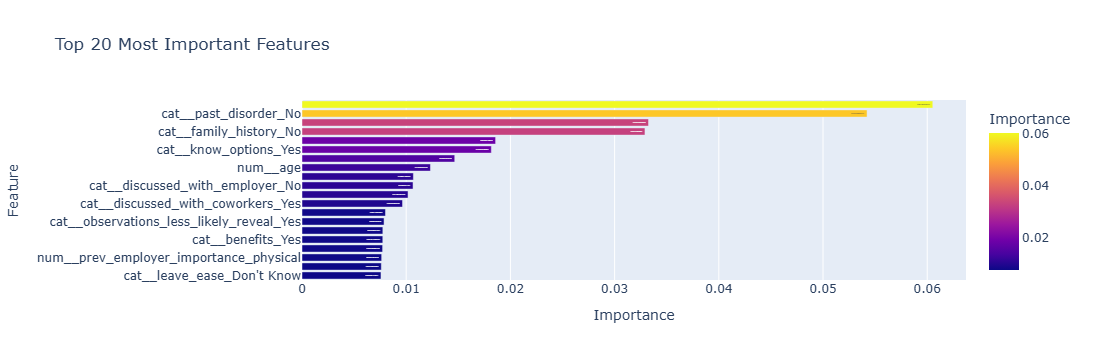

In [7]:
top20 = feature_importance.head(20)

fig = px.bar(

    top20,

    x="Importance",

    y="Feature",

    orientation="h",

    color="Importance",

    text="Importance",

    title="Top 20 Most Important Features"

)

fig.update_layout(

    yaxis=dict(

        categoryorder="total ascending"

    )

)

fig.show()

## Save Feature Importance

In [8]:
Path("../results").mkdir(

    parents=True,

    exist_ok=True

)

feature_importance.to_csv(

    "../results/feature_importance.csv",

    index=False

)

print("Feature importance saved.")

Feature importance saved.


In [9]:
import shap
import numpy as np
import scipy

print("SHAP :", shap.__version__)
print("NumPy:", np.__version__)
print("SciPy:", scipy.__version__)

SHAP : 0.52.0
NumPy: 2.3.4
SciPy: 1.18.0


In [24]:
from scipy import sparse
import numpy as np

# Convert sparse -> dense
if sparse.issparse(X_transformed):
    X_dense = X_transformed.toarray()
else:
    X_dense = np.asarray(X_transformed)

# Ensure numeric dtype
X_dense = X_dense.astype(np.float64)

print(type(X_dense))
print(X_dense.dtype)
print(X_dense.shape)

<class 'numpy.ndarray'>
float64
(3082, 304)


In [ ]:
explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(X_dense)

In [ ]:
print(X_dense.dtype)
print(np.isnan(X_dense).sum())

In [23]:
X_transformed = preprocessor.transform(X)

In [16]:
print(type(X_transformed))

<class 'scipy.sparse._csr.csr_matrix'>


In [18]:
print(best_model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['survey_year',
                                                   'employer_importance_physical',
                                                   'employer_importance_mental',
                                                   'have_prev_employers',
                                                   'prev_employer_importance_physical',
                                                   'prev_employer_importance_mental',
                                                   'share_with_friends_f...
           

In [19]:
for name, transformer, cols in preprocessor.transformers_:
    print("=" * 60)
    print(name)
    print(type(transformer))
    print(cols)

num
<class 'sklearn.pipeline.Pipeline'>
['survey_year', 'employer_importance_physical', 'employer_importance_mental', 'have_prev_employers', 'prev_employer_importance_physical', 'prev_employer_importance_mental', 'share_with_friends_family', 'industry_support_rating', 'age', 'workplace_support_score']
cat
<class 'sklearn.pipeline.Pipeline'>
['self_employed', 'no_employees', 'tech_company', 'primary_role_tech', 'benefits', 'know_options', 'formal_discussion', 'resources', 'anonymity', 'leave_ease', 'comfort_physical_mental', 'comfort_supervisor', 'discussed_with_employer', 'comfort_coworkers', 'discussed_with_coworkers', 'coworker_discussed_with_you', 'productivity_affected', 'prev_tech_company', 'prev_benefits', 'prev_know_options', 'prev_formal_discussion', 'prev_resources', 'prev_anonymity', 'prev_comfort_physical_mental', 'prev_comfort_supervisor', 'prev_discussed_with_employer', 'prev_comfort_coworkers', 'prev_discussed_with_coworkers', 'past_disorder', 'family_history', 'observati

In [20]:
X_check = preprocessor.transform(X)

print(type(X_check))

if hasattr(X_check, "dtype"):
    print(X_check.dtype)

print(X_check.shape)

<class 'scipy.sparse._csr.csr_matrix'>
float64
(3082, 304)
